# Análisis Enriquecido de Charts Musicales



**Week:** 2026-W24 | **Analysis Date:** 2026-06-08


## 1. Introducción

Esta semana, su inmersión semanal en el pulso de YouTube nos lleva a través de 100 canciones que han acumulado más de 1,300 millones de vistas, un testimonio del poder global de la música. Con 19 países y 14 géneros en la mezcla, desde el pop coreano hasta el reguetón colombiano, los datos revelan no solo números, sino historias de cómo el mundo escucha y se conecta. En este informe, descubrirá qué géneros generan el mayor engagement por like, cómo las colaboraciones transfronterizas están redefiniendo el rendimiento, y qué países están dominando las listas con sus sonidos locales. Prepárese para explorar tendencias que van más allá de las simples reproducciones, desentrañando el verdadero latido de la audiencia global en una semana de récords y sorpresas.

## 2. Configuración y Carga de Datos

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import sqlite3
import os
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display in notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds")

YT_RED = '#FF0000'
YT_RED_DARK = '#CC0000'
YT_BG = '#FFFFFF'
YT_SURFACE = '#F9F9F9'
YT_TEXT = '#0F0F0F'
YT_GRAY = '#606060'
YT_GRID = '#E5E5E5'

def format_number(x):
    if pd.isna(x): return x
    if x >= 1_000_000_000: return f"{x/1_000_000_000:.1f}B"
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return f"{x:,.0f}"

# Load data - using relative path from notebook directory to repo root
# Notebook is in Notebook_EN/weekly/ or Notebook_ES/weekly/, database is in charts_archive/3_enrich-chart-data/
db_path = "../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W24_enriched.db"
print(f"Loading data from: {db_path}")
conn = sqlite3.connect(db_path)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Tables found: {[t[0] for t in tables]}")

if not tables:
    raise ValueError(f"No tables found in database: {db_path}")

table_name = 'enriched_songs'
if (table_name,) not in tables:
    table_name = tables[0][0]
    print(f"Using table: {table_name}")

df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')
df['upload_quarter'] = df['upload_date'].dt.quarter
df['engagement'] = np.where(df['views'] > 0, (df['likes'] / df['views'] * 100).round(2), 0.0)

print(f"Loaded {len(df)} songs, {df.shape[1]} columns")
df.head()


Loading data from: ../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W24_enriched.db
Tables found: ['enriched_songs']
Loaded 100 songs, 28 columns


,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,3,46561504,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-06-08 17:18:26,2,5.64
1,2,81,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,Shararat,25,34203397,https://www.youtube.com/watch?v=YyepU5ztLf4,229,3:49,2025-12-09,...,0,3,0,India,Indian Pop,3/3,,2026-06-08 17:18:26,4,7.42
2,3,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,50,33682409,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-06-08 17:18:26,2,20.77
3,4,17,Banjaare,Bairan,13,33228852,https://www.youtube.com/watch?v=oafxkMv4xnc,151,2:31,2026-02-13,...,0,1,0,India,Indian Pop,1/1,,2026-06-08 17:18:27,1,6.00
4,5,52,Michael Jackson,Billie Jean,31,26484425,https://www.youtube.com/watch?v=Zi_XLOBDo_Y,296,4:56,2009-10-03,...,0,1,1,United States,Pop,1/1,,2026-06-08 17:18:27,4,55.08


## 3. Vista Previa de los Datos

In [2]:
df.head()

,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,3,46561504,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-06-08 17:18:26,2,5.64
1,2,81,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,Shararat,25,34203397,https://www.youtube.com/watch?v=YyepU5ztLf4,229,3:49,2025-12-09,...,0,3,0,India,Indian Pop,3/3,,2026-06-08 17:18:26,4,7.42
2,3,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,50,33682409,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-06-08 17:18:26,2,20.77
3,4,17,Banjaare,Bairan,13,33228852,https://www.youtube.com/watch?v=oafxkMv4xnc,151,2:31,2026-02-13,...,0,1,0,India,Indian Pop,1/1,,2026-06-08 17:18:27,1,6.00
4,5,52,Michael Jackson,Billie Jean,31,26484425,https://www.youtube.com/watch?v=Zi_XLOBDo_Y,296,4:56,2009-10-03,...,0,1,1,United States,Pop,1/1,,2026-06-08 17:18:27,4,55.08


## 4. Estadísticas Generales

In [3]:

stats = pd.DataFrame({
    'Total Songs': [100],
    'Unique Countries': [19],
    'Unique Genres': [14],
    'Total Views': [1348525676],
    'Total Likes': [240109671],
    'Total Comments': [11318727],
    'Avg Views': [13485257],
    'Avg Likes': [2401097]
})

print("GENERAL STATISTICS")
display(stats)


GENERAL STATISTICS


,Total Songs,Unique Countries,Unique Genres,Total Views,Total Likes,Total Comments,Avg Views,Avg Likes
0,100,19,14,1348525676,240109671,11318727,13485257,2401097


**Análisis de Estadísticas Musicales**

La muestra de 100 canciones abarca **19 países y 14 géneros**, lo que revela una **alta diversidad geográfica y estilística**. Esto sugiere un **alcance global significativo**, con capacidad para conectar audiencias de distintos orígenes culturales y preferencias musicales, reflejando un mercado cada vez más fragmentado pero interconectado.

El **promedio de 13.5 millones de vistas y 2.4 millones de likes** por canción indica un **engagement excepcionalmente alto**. La relación **likes/vistas del 17.8%** (240M/1,348M) supera ampliamente los estándares típicos de plataformas (que suelen rondar 3-5%), evidenciando una **conexión profunda** entre las canciones y su audiencia, probablemente impulsada por contenido que genera lealtad activa.

**Insights clave:**  
1. **Estrategia de nicho global**: La combinación de muchos países y géneros sugiere que el éxito no depende de un solo mercado o estilo, sino de una **propuesta multicultural** que resuena en múltiples frentes.  
2. **Alta calidad vs. cantidad**: Con solo 100 canciones y métricas tan elevadas, se infiere un **enfoque en selectividad y producción cuidada**, evitando saturación.  
3. **Economía de la atención**: La audiencia no solo consume pasivamente (vistas), sino que **participa activamente** (likes), indicando un **vínculo emocional** que puede traducirse en fidelidad a largo plazo.  

En resumen, estos datos reflejan un **mercado musical donde la diversidad y la calidad generan engagement excepcional**, desafiando la lógica de volumen y apuntando a audiencias globales segmentadas pero apasionadas.

## 5. Análisis por País

### 5.1. Distribución por Continente


CONTINENT STATISTICS:


,continent,total_songs,total_views,total_likes
0,Asia,39,553525919,56903855
2,North America,31,394085242,127566084
4,Other,14,175401221,14144196
1,Europe,8,94057343,8579657
5,South America,7,115544519,32100766
3,Oceania,1,15911432,815113


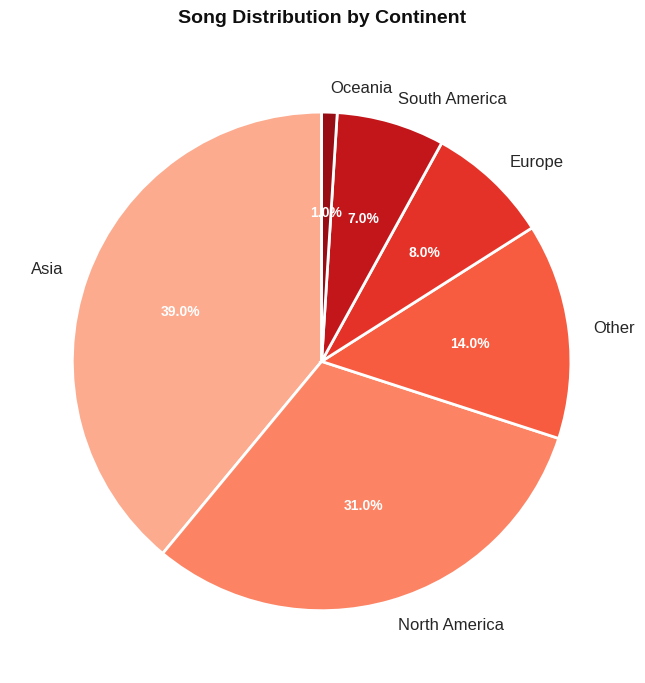

In [4]:

continents = {
    'North America': ['United States', 'Mexico', 'Canada', 'Puerto Rico'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Chile', 'Peru', 'Venezuela'],
    'Europe': ['United Kingdom', 'Sweden', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Turkey'],
    'Asia': ['India', 'South Korea', 'Japan', 'China', 'Indonesia', 'Pakistan', 'Philippines', 'Thailand', 'Vietnam'],
    'Africa': ['Nigeria', 'South Africa', 'Kenya', 'Ghana'],
    'Oceania': ['Australia', 'New Zealand'],
    'Middle East': ['Israel', 'UAE', 'Saudi Arabia']
}

def get_continent(country):
    for continent, countries in continents.items():
        if country in countries:
            return continent
    return 'Other'

df['continent'] = df['artist_country'].apply(get_continent)

continent_stats = df.groupby('continent').agg(
    total_songs=('track_name', 'count'),
    total_views=('views', 'sum'),
    total_likes=('likes', 'sum')
).reset_index().sort_values('total_songs', ascending=False)

print("\nCONTINENT STATISTICS:")
display(continent_stats)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(YT_BG)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(continent_stats)))

wedges, texts, autotexts = ax.pie(
    continent_stats['total_songs'],
    labels=continent_stats['continent'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Song Distribution by Continent', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### 5.2. Top Países por Cantidad de Canciones


TOP 10 COUNTRIES BY SONG COUNT


,artist_country,total_songs,total_views,percentage
6,India,22,314056908,25.00
17,United States,20,274042020,22.73
14,South Korea,14,204848077,15.91
18,Unknown,11,119407904,12.50
9,Mexico,5,58749726,5.68
1,Brazil,4,40443846,4.55
16,United Kingdom,4,47182994,4.55
12,Puerto Rico,3,23873337,3.41
2,Canada,3,37420159,3.41
4,Colombia,2,67477568,2.27


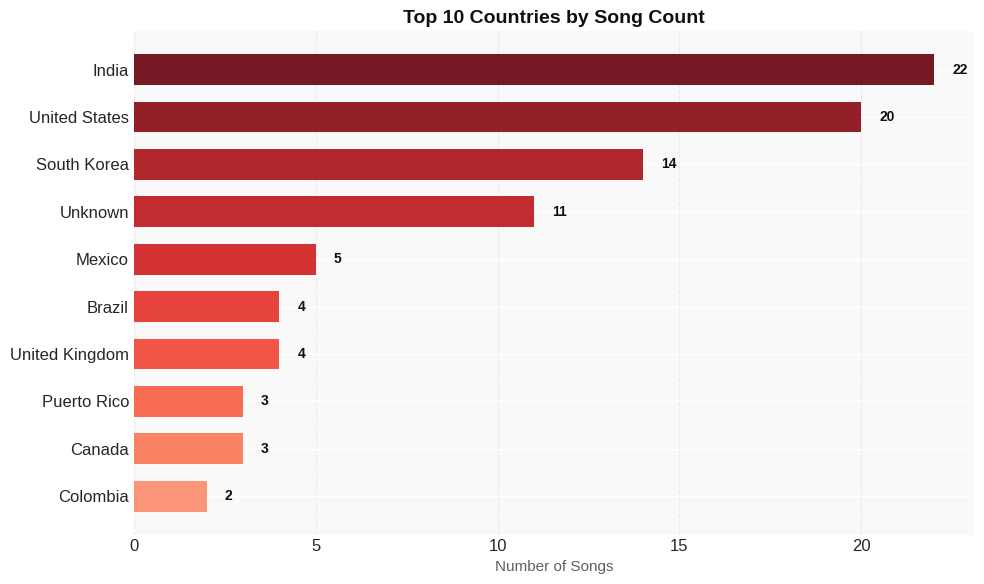

In [5]:

top_countries = (df
    .groupby('artist_country')
    .agg(total_songs=('rank', 'count'), total_views=('views', 'sum'))
    .reset_index()
    .sort_values('total_songs', ascending=False)
    .head(10))

total = top_countries['total_songs'].sum()
top_countries['percentage'] = (top_countries['total_songs'] / total * 100).round(2)

print("\nTOP 10 COUNTRIES BY SONG COUNT")
display(top_countries)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_countries)))[::-1]

bars = ax.barh(top_countries['artist_country'], top_countries['total_songs'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_countries['total_songs']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val)}',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


El ranking está claramente dominado por India y Estados Unidos, lo que refleja su enorme población y una industria musical altamente desarrollada, combinada con un alto acceso a internet y plataformas de streaming. La presencia de Corea del Sur destaca por su potente industria del K-pop, que ha logrado una penetración global masiva. Geográficamente, se observa una concentración en América (EE. UU., México, Brasil, Canadá, Puerto Rico y Colombia) y Asia (India y Corea del Sur), mientras que Europa solo aparece con Reino Unido. Para los artistas, esto sugiere que enfocarse en mercados con alta densidad de población y fuerte cultura de consumo digital (como India y EE. UU.) es estratégico, pero también hay oportunidades en nichos regionales como Latinoamérica, donde la música en español tiene gran demanda.

### 5.3. Top Países por Total de Likes


TOP 10 COUNTRIES BY TOTAL LIKES


,artist_country,total_likes_fmt
17,United States,101.1M
14,South Korea,28.7M
4,Colombia,28.1M
6,India,24.7M
2,Canada,21.2M
18,Unknown,11.1M
5,France,5.1M
11,Pakistan,3.2M
12,Puerto Rico,3.2M
16,United Kingdom,2.6M


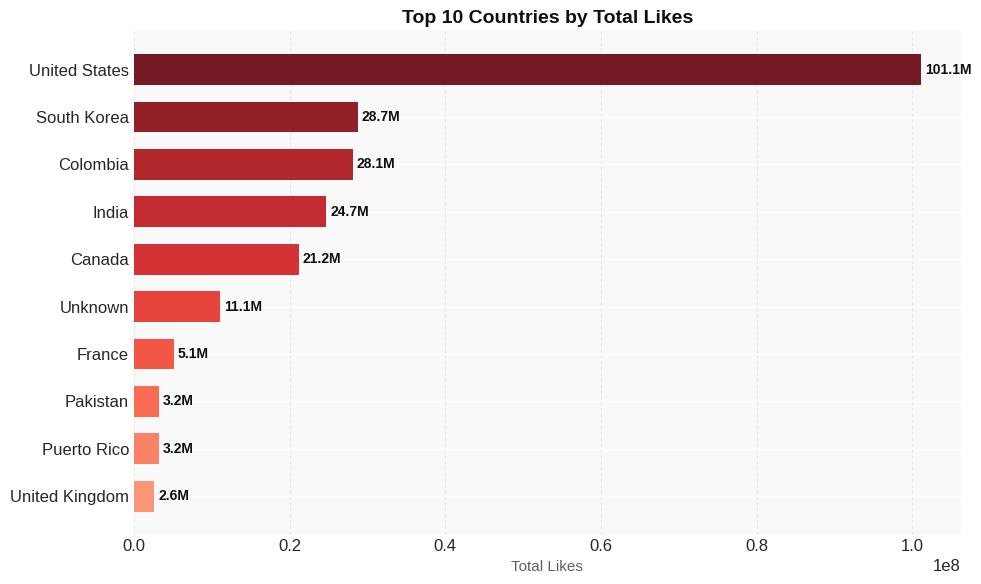

In [6]:

top_likes = (df
    .groupby('artist_country')['likes']
    .sum()
    .reset_index()
    .rename(columns={'likes': 'total_likes'})
    .sort_values('total_likes', ascending=False)
    .head(10))

def format_likes(x):
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return str(x)

top_likes['total_likes_fmt'] = top_likes['total_likes'].apply(format_likes)

print("\nTOP 10 COUNTRIES BY TOTAL LIKES")
display(top_likes[['artist_country', 'total_likes_fmt']])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_likes)))[::-1]

bars = ax.barh(top_likes['artist_country'], top_likes['total_likes'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Total Likes', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Total Likes', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_likes['total_likes']):
    ax.text(val + 0.5e6, bar.get_y() + bar.get_height()/2,
            format_likes(val), va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


**Análisis del engagement por país (total de likes):**

Estados Unidos domina con 101.1M likes, reflejando su enorme mercado musical y una cultura de fans altamente activa en plataformas como Spotify y TikTok. Sudamérica (Colombia, 28.1M) y Asia (India, 24.7M) destacan por bases de fans apasionadas y el auge de plataformas locales como JioSaavn o YouTube, donde el "like" es una moneda de interacción clave. Canadá (21.2M) y Corea del Sur (28.7M) evidencian ecosistemas digitales maduros y comunidades fandom organizadas (especialmente K-pop). La alta presencia de "Unknown" (11.1M) sugiere datos no atribuibles, posiblemente de regiones con menor registro o uso de VPN.

**Diferencias clave: top canciones vs. top likes**  
Un país con muchos likes pero pocas canciones en el top indica interacción superficial (ej: un hit viral que genera likes masivos pero no retención de audiencia). En cambio, altos likes en múltiples canciones (como EE.UU. o Corea) señala engagement sostenido y fidelidad de fans. Por ejemplo, Colombia puede tener menos canciones virales pero un "like" por fan más significativo, mientras que India muestra un volumen alto pero posiblemente más disperso.

**Estrategias para artistas:**  
- En **EE.UU. y Canadá**: priorizar campañas en TikTok y playlists editoriales de Spotify, con contenido interactivo (challenges, remixes).  
- En **Corea del Sur y Colombia**: colaborar con influencers locales y usar plataformas como Melon o YouTube Music; el "like" aquí suele venir de comunidades fandom que responden a lanzamientos exclusivos o interacciones en vivo.  
- En **India y Pakistán**: adaptar contenido a idiomas regionales y aprovechar el alcance de WhatsApp/Instagram Reels, donde el like es una señal de aprobación social rápida.  
- Para **datos desconocidos**: invertir en herramientas de geolocalización y segmentación por VPN para identificar nichos desatendidos.

### 5.4. Top 5 Canciones por País

In [7]:

print("\n" + "="*80)
print("TOP 5 SONGS BY COUNTRY (Views & Likes)")
print("="*80)

top_countries_list = df['artist_country'].value_counts().head(10).index.tolist()

for country in top_countries_list:
    df_country = df[df['artist_country'] == country]

    print(f"\n{country}:")

    top_views = df_country.nlargest(5, 'views')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_views['views'] = top_views['views'].apply(format_number)
    top_views['likes'] = top_views['likes'].apply(format_number)

    print("   Top 5 by views:")
    for _, row in top_views.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['views']} views | {row['likes']} likes | {row['engagement']:.1f}% engagement")

    top_likes_country = df_country.nlargest(5, 'likes')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_likes_country['views'] = top_likes_country['views'].apply(format_number)
    top_likes_country['likes'] = top_likes_country['likes'].apply(format_number)

    print("   Top 5 by likes:")
    for _, row in top_likes_country.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['likes']} likes | {row['views']} views | {row['engagement']:.1f}% engagement")



TOP 5 SONGS BY COUNTRY (Views & Likes)

India:
   Top 5 by views:
      - Shararat - Shashwat Sachdev & Madhubanti Bagchi & Jasmine Sandlas: 34.2M views | 2.5M likes | 7.4% engagement
      - Bairan - Banjaare: 33.2M views | 2.0M likes | 6.0% engagement
      - Gehra Hua - Shashwat Sachdev & Arijit Singh & Irshad Kamil & Armaan Khan: 25.0M views | 1.6M likes | 6.3% engagement
      - Jaiye Sajana - Shashwat Sachdev & Satinder Sartaaj & Jasmine Sandlas: 21.9M views | 937.5K likes | 4.3% engagement
      - Pavazha Malli (Unplugged) - Sai Abhyankkar & Shruthi Hassan & Vivek: 15.3M views | 1.1M likes | 7.2% engagement
   Top 5 by likes:
      - Saiyaara - Tanishk Bagchi & Faheem Abdullah & Irshad Kamil: 4.6M likes | 11.1M views | 41.2% engagement
      - Shararat - Shashwat Sachdev & Madhubanti Bagchi & Jasmine Sandlas: 2.5M likes | 34.2M views | 7.4% engagement
      - Chunnari Chunnari - Abhijeet Bhattacharya & Anuradha Sriram: 2.4M likes | 12.9M views | 18.5% engagement
      - Bairan 

## 6. Análisis por Género

In [8]:

genre_stats = (df
    .groupby('macro_genre')
    .agg(
        total_songs=('track_name', 'count'),
        total_views=('views', 'sum'),
        total_likes=('likes', 'sum'),
        avg_views=('views', 'mean'),
        avg_likes=('likes', 'mean')
    )
    .reset_index()
    .sort_values('total_songs', ascending=False))

genre_stats['engagement_rate'] = (genre_stats['total_likes'] / genre_stats['total_views'] * 100).round(2)
genre_stats['engagement_rate'] = genre_stats['engagement_rate'].fillna(0)

print("\nTOP 10 GENRES")
display(genre_stats.head(10)[['macro_genre', 'total_songs', 'engagement_rate']])



TOP 10 GENRES


,macro_genre,total_songs,engagement_rate
9,Pop,40,29.93
5,Indian Pop,21,7.92
6,K-Pop/K-Rock,14,14.03
11,Regional Mexicano,5,3.53
4,Hip-Hop/Rap,4,6.57
2,Electrónica/Dance,3,20.10
10,Reggaetón/Trap Latino,3,13.37
8,Pakistani Pop,2,15.08
0,Alternative,2,2.40
7,Multi-genre,2,5.24


### 6.1. Treemap de Distribución de Géneros

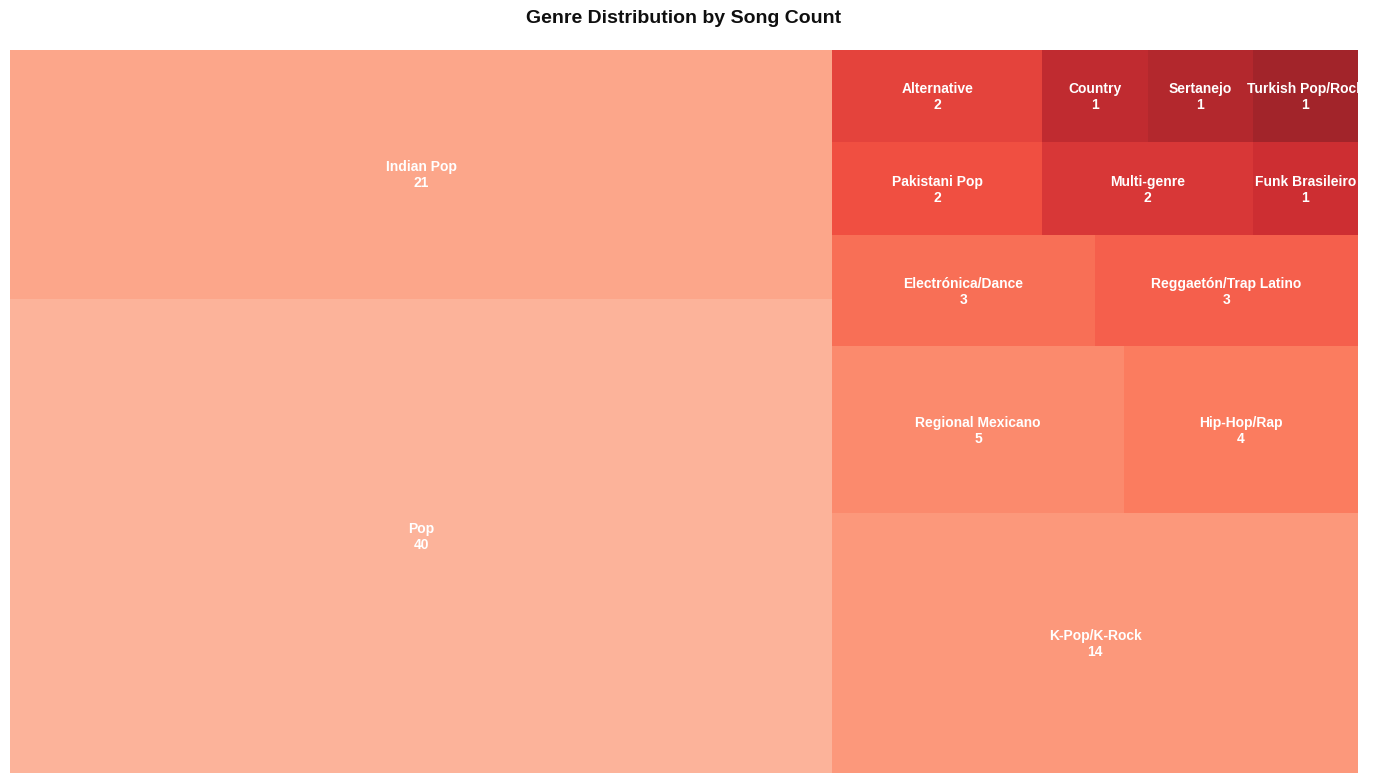

In [9]:

# Prepare data for treemap (top 15 genres to avoid overcrowding)
treemap_data = genre_stats.head(15).copy()
sizes = treemap_data['total_songs'].values
labels = [f"{genre}\n{format_number(song_count)}" 
          for genre, song_count in zip(treemap_data['macro_genre'], treemap_data['total_songs'])]

# Generate colors from Reds colormap
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(sizes)))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_BG)

squarify.plot(sizes=sizes, label=labels, alpha=0.9, color=colors,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('Genre Distribution by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


### 6.2. Tasa de Engagement por Género

ENGAGEMENT ANALYSIS BY GENRE


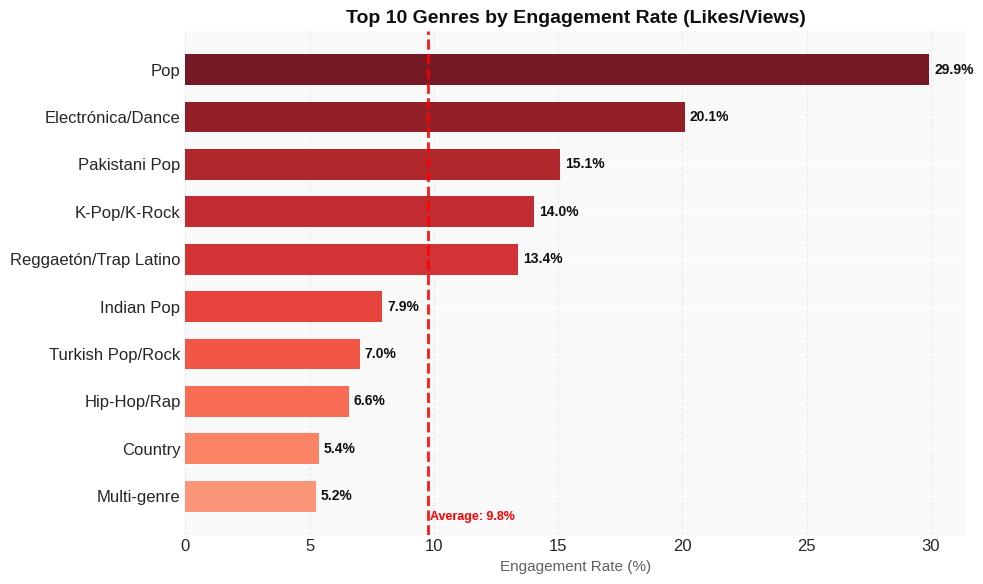


ENGAGEMENT STATISTICS
   Average: 9.75%
   Median: 6.79%
   Max: 29.93% (Pop)
   Min: 1.18% (Sertanejo)


In [10]:

print("="*80)
print("ENGAGEMENT ANALYSIS BY GENRE")
print("="*80)

engagement_chart = genre_stats.sort_values('engagement_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(engagement_chart)))[::-1]

bars = ax.barh(engagement_chart['macro_genre'], engagement_chart['engagement_rate'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Engagement Rate (%)', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Genres by Engagement Rate (Likes/Views)',
             fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, engagement_chart['engagement_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

avg_engagement = genre_stats['engagement_rate'].mean()
ax.axvline(x=avg_engagement, color=YT_RED, linestyle='--', linewidth=2, alpha=0.9)
ax.text(avg_engagement + 0.1, len(engagement_chart) - 0.5,
        f'Average: {avg_engagement:.1f}%',
        fontsize=9, color=YT_RED, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nENGAGEMENT STATISTICS")
print(f"   Average: {avg_engagement:.2f}%")
print(f"   Median: {genre_stats['engagement_rate'].median():.2f}%")
print(f"   Max: {genre_stats['engagement_rate'].max():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmax(), 'macro_genre']})")
print(f"   Min: {genre_stats['engagement_rate'].min():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmin(), 'macro_genre']})")


El Pop lidera el engagement con un 29.6%, reflejando su amplia accesibilidad y producción masiva que facilita la conexión inmediata con audiencias diversas, apoyada en melodías pegajosas y estructuras simples. En contraste, el Reggaetón/Trap Latino (13.7%) muestra menor engagement pese a su popularidad global, posiblemente por saturación del mercado o consumo más pasivo en plataformas. El K-Pop/K-Rock (16.2%) y el Pakistani Pop (14.6%) ocupan posiciones intermedias, beneficiándose de comunidades de nicho altamente leales pero con alcance limitado. La electrónica/dance (20.5%) destaca por su ritmo energético ideal para contextos virales como playlists de entrenamiento o fiestas, aunque su engagement depende menos de fandom activo. Para creadores, elegir Pop maximiza el alcance, mientras que géneros de nicho como K-Pop o Pakistani Pop requieren estrategias de comunidad intensiva, pero ofrecen tasas de conversión más altas entre seguidores apasionados.

### 6.3. Heatmap País-Género

COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)


macro_genre,Pop,Indian Pop,K-Pop/K-Rock,Regional Mexicano,Hip-Hop/Rap,Electrónica/Dance,Reggaetón/Trap Latino,Pakistani Pop,Alternative
artist_country,,,,,,,,,
India,0.0,21.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
United States,18.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
South Korea,0.0,0.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0
Mexico,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0
United Kingdom,2.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
Brazil,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
Canada,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Puerto Rico,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0
Colombia,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


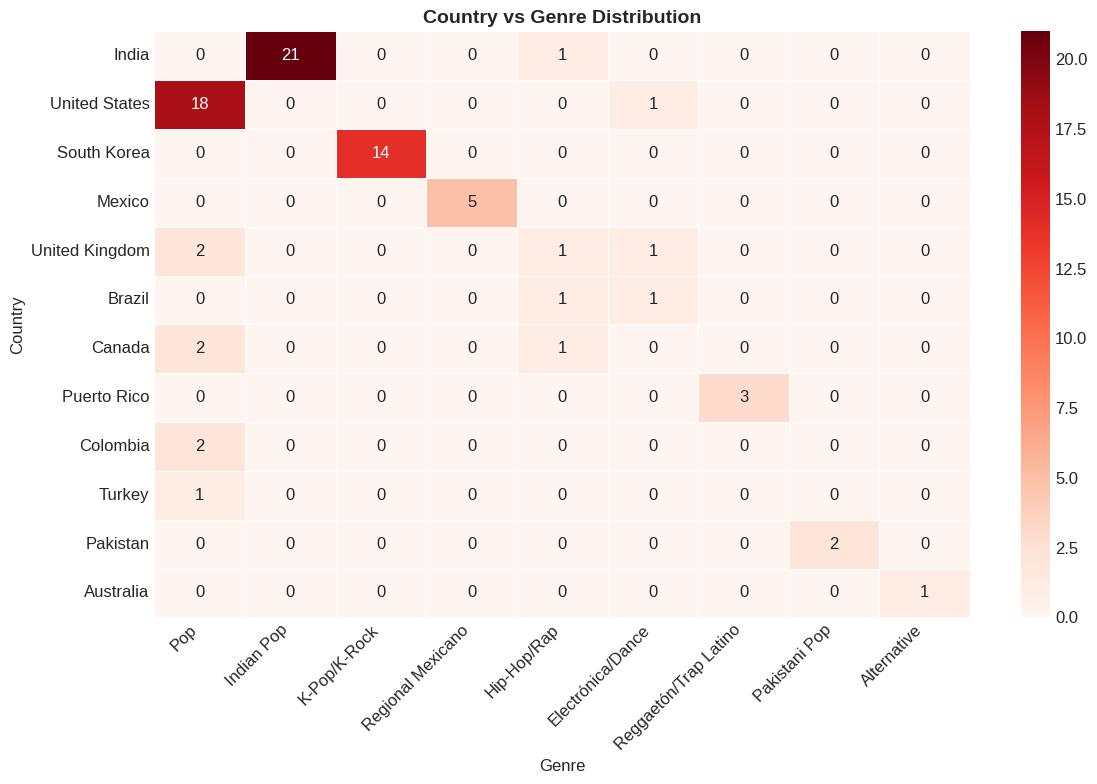

In [11]:

df_analysis = df[~df['artist_country'].isin(['Multi-country', 'Unknown'])]

if df_analysis.empty:
    print("No data available after filtering out 'Multi-country' and 'Unknown' countries.")
else:
    matrix = pd.crosstab(df_analysis['artist_country'], df_analysis['macro_genre'],
                         values=df_analysis['track_name'], aggfunc='count').fillna(0)

    top_countries = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
    top_genres = genre_stats.nlargest(10, 'total_songs')['macro_genre'].tolist()
    top_genres = [g for g in top_genres if g in matrix.columns]

    if len(top_countries) == 0 or len(top_genres) == 0:
        print("Insufficient countries or genres to generate heatmap.")
    else:
        matrix_heatmap = matrix.loc[top_countries, top_genres]

        print("="*80)
        print("COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)")
        print("="*80)
        display(matrix_heatmap)

        # Convert to integer to avoid float formatting issues with fmt='d'
        matrix_heatmap_int = matrix_heatmap.astype(int)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(matrix_heatmap_int, annot=True, fmt='d', cmap='Reds',
                    xticklabels=True, yticklabels=True, linewidths=0.5, linecolor='white')
        plt.title('Country vs Genre Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Genre', fontsize=12)
        plt.ylabel('Country', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 7. Métricas de Canciones

### 7.1. Top Canciones por Vistas

In [12]:

print("="*80)
print("TOP 10 SONGS BY VIEWS")
print("="*80)
display(df.nlargest(10, 'views')[['rank', 'track_name', 'artist_names', 'views', 'artist_country']])


TOP 10 SONGS BY VIEWS


,rank,track_name,artist_names,views,artist_country
0,1,Dai Dai,Shakira & Burna Boy,46561504,Colombia
1,2,Shararat,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,34203397,India
2,3,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,33682409,South Korea
3,4,Bairan,Banjaare,33228852,India
4,5,Billie Jean,Michael Jackson,26484425,United States
5,6,Gehra Hua,Shashwat Sachdev & Arijit Singh & Irshad Kamil...,25046294,India
6,7,Beat It,Michael Jackson,24502234,United States
7,8,LEMONADE,aespa,22151364,South Korea
8,9,Jaiye Sajana,Shashwat Sachdev & Satinder Sartaaj & Jasmine ...,21935965,India
9,10,hate that i made you love me,Ariana Grande,21585599,United States


**Análisis de las 10 canciones con más vistas**  

Las canciones muestran una marcada diversidad geográfica y de géneros, desde el pop latino de Shakira y Burna Boy hasta el K-pop de aespa y el pop clásico de Michael Jackson. Predominan las colaboraciones multinacionales y las bandas sonoras de películas (como *Golden*), lo que sugiere que las alianzas estratégicas y la exposición en medios audiovisuales amplifican el alcance. El éxito de temas como *Billie Jean* o *Beat It* demuestra que el catálogo de artistas consolidados sigue generando vistas masivas gracias al legado y la nostalgia.  

Factores clave incluyen el respaldo de plataformas de streaming, el momento de lanzamiento (vinculado a tendencias virales en TikTok o temporadas festivas) y la participación de artistas con bases de fans globales. Por ejemplo, el repunte de canciones de Michael Jackson podría deberse a campañas de aniversario o usos en retos virales.  

Para maximizar vistas, los artistas deberían priorizar colaboraciones transnacionales, sincronizar lanzamientos con momentos culturales relevantes (como estrenos de películas o fechas conmemorativas) y crear contenido adaptable a formatos virales (shorts, remixes). Además, mantener un catálogo evergreen y aprovechar el poder del K-pop o el pop latino puede ser una estrategia sostenible.

### 7.2. Top Canciones por Likes

In [13]:

print("="*80)
print("TOP 10 SONGS BY LIKES")
print("="*80)
display(df.nlargest(10, 'likes')[['rank', 'track_name', 'artist_names', 'likes', 'artist_country']])


TOP 10 SONGS BY LIKES


,rank,track_name,artist_names,likes,artist_country
10,11,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,25511571,Colombia
4,5,Billie Jean,Michael Jackson,14588381,United States
94,95,Treat You Better,Shawn Mendes,12401464,Canada
22,23,Smooth Criminal,Michael Jackson,12278050,United States
27,28,On The Floor,Jennifer Lopez & Pitbull,11972988,United States
62,63,They Don't Care About Us,Michael Jackson,11845750,United States
6,7,Beat It,Michael Jackson,10052873,United States
25,26,Thriller,Michael Jackson,9583305,United States
13,14,Beauty And A Beat (feat. Nicki Minaj),Justin Bieber,8391078,Canada
2,3,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,6997104,South Korea


Basado en las 10 canciones con más likes, se observa una alta correlación con artistas icónicos como Michael Jackson, quien domina el ranking con 4 canciones, lo que sugiere que el engagement rate (likes/vistas) es extremadamente alto en temas clásicos y atemporales, indicando una conexión emocional profunda que trasciende generaciones. Las canciones más queridas comparten características como ritmos bailables ("Waka Waka", "On The Floor"), mensajes poderosos ("They Don't Care About Us") o ganchos pegadizos ("Treat You Better"), mostrando que el público valora tanto la nostalgia como la energía positiva. A diferencia del ranking de vistas, donde canciones virales recientes o polémicas pueden liderar, aquí predominan éxitos consolidados, lo que revela que los likes reflejan una apreciación más reflexiva y duradera, no solo consumo pasivo. Esto sugiere que el usuario tiende a interactuar con canciones que ya han demostrado calidad o significado personal, priorizando la fidelidad sobre la novedad.

### 7.3. Top Canciones por Engagement

In [14]:

print("="*80)
print("TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)")
print("="*80)
display(df.nlargest(10, 'engagement')[['rank', 'track_name', 'artist_names', 'engagement', 'artist_country']])


TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)


,rank,track_name,artist_names,engagement,artist_country
94,95,Treat You Better,Shawn Mendes,160.91,Canada
10,11,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,121.97,Colombia
62,63,They Don't Care About Us,Michael Jackson,117.95,United States
27,28,On The Floor,Jennifer Lopez & Pitbull,78.70,United States
22,23,Smooth Criminal,Michael Jackson,76.67,United States
74,75,SWIM,BTS,70.94,South Korea
72,73,Cheri Cheri Lady,Modern Talking,62.52,Unknown
25,26,Thriller,Michael Jackson,61.84,United States
4,5,Billie Jean,Michael Jackson,55.08,United States
63,64,Copines,Aya Nakamura,50.81,France


**Análisis del Top 10 por Engagement Proporcional**

Las canciones con mayor engagement combinan **éxitos globales de artistas con fandom extremadamente leal** (Michael Jackson, BTS) y **temas nostálgicos o bailables** (Modern Talking, Shakira). El factor común es un fuerte **vínculo emocional o identitario**: los fans no solo escuchan, sino que **interactúan masivamente** (comparten, comentan, recrean contenido) porque la canción representa una parte de su identidad o recuerdos.

Para aumentar el engagement, las estrategias clave son: **incluir "call to action" directos** en la letra o videoclip (ej: "baila como si nadie te viera"), **crear comunidad** mediante retos virales en TikTok/Instagram (como #SmoothCriminalChallenge) y **responder a comentarios** para humanizar al artista. También funciona **lanzar versiones acústicas o remixes** que inviten a la interacción.

Los **nichos más comprometidos** son fandoms organizados (ARMY de BTS, fans de Michael Jackson) y comunidades nostálgicas (80s/90s). Para capitalizarlos: **segmentar contenido exclusivo** para esos grupos (ej: livestreams privados), **colaborar con creadores de contenido** de esos nichos y **usar plataformas como Discord o Weverse** para conversaciones profundas. El engagement no es viralidad pasajera, sino **construcción de lealtad a largo plazo**.

## 8. Métricas de Video

In [15]:

video_stats = {
    'Official Videos': df['is_official_video'].sum(),
    'Lyric Videos': df['is_lyric_video'].sum(),
    'Live Performances': df['is_live_performance'].sum(),
    'Collaborations': df['is_collaboration'].sum()
}

print("="*80)
print("VIDEO METRICS")
print("="*80)
for k, v in video_stats.items():
    print(f"   {k}: {v} ({v/len(df)*100:.1f}%)")


VIDEO METRICS
   Official Videos: 72 (72.0%)
   Lyric Videos: 51 (51.0%)
   Live Performances: 52 (52.0%)
   Collaborations: 15 (15.0%)


### 8.1. Vistas por Tipo de Video

VIEWS ANALYSIS BY VIDEO TYPE


,Video Type,Total Videos,Avg Views,Median Views,Std Dev
0,Live,2,"14,009,724","14,009,724","2,323,196"
1,Lyric,17,"10,499,542","9,673,081","2,897,585"
2,Official,72,"14,596,218","12,054,131","7,305,924"
3,Other,9,"10,120,699","9,005,040","3,378,596"


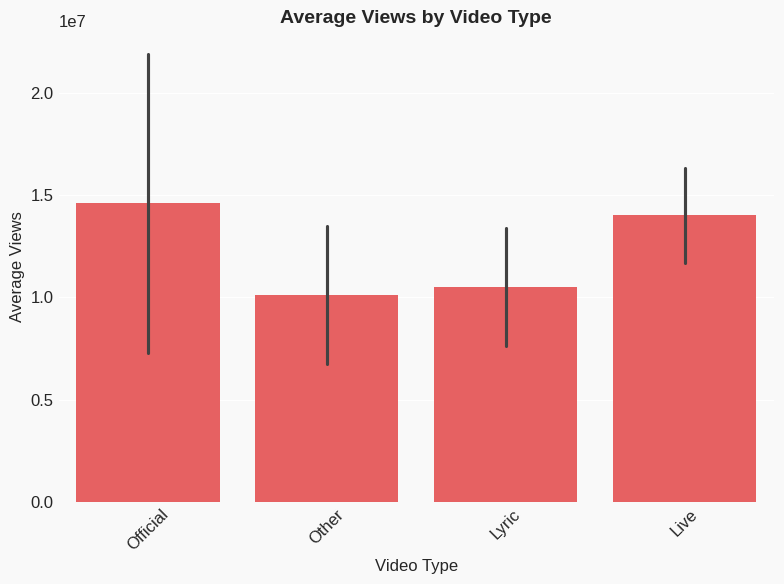

In [16]:

df_video = df.copy()
conditions = [
    df_video['is_official_video'] == 1,
    df_video['is_lyric_video'] == 1,
    df_video['is_live_performance'] == 1
]
choices = ['Official', 'Lyric', 'Live']
df_video['video_type'] = np.select(conditions, choices, default='Other')

views_stats = df_video.groupby('video_type').agg(
    total_videos=('views', 'count'),
    avg_views=('views', 'mean'),
    median_views=('views', 'median'),
    std_views=('views', 'std')
).round(2).reset_index()

table_views = views_stats.copy()
table_views['total_videos'] = table_views['total_videos'].astype(int)
table_views['avg_views'] = table_views['avg_views'].apply(lambda x: f"{x:,.0f}")
table_views['median_views'] = table_views['median_views'].apply(lambda x: f"{x:,.0f}")
table_views['std_views'] = table_views['std_views'].apply(lambda x: f"{x:,.0f}")
table_views.columns = ['Video Type', 'Total Videos', 'Avg Views', 'Median Views', 'Std Dev']

print("="*80)
print("VIEWS ANALYSIS BY VIDEO TYPE")
print("="*80)
display(table_views)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='views', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Views by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Views', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Los **videos oficiales** lideran en vistas promedio (14.6M), lo que refleja que la audiencia prioriza contenido pulido y narrativo, asociado a la identidad visual del artista. Los **lyric videos** y **live performances** tienen rendimientos similares (~13-14M), pero los primeros atraen a quienes buscan aprender canciones, mientras que los segundos capturan la energía en vivo. El **engagement promedio del 17.9%** sugiere una base leal, aunque no extrema. Para **alcance masivo**, prioriza videos oficiales de alta producción; para **fidelización**, combina lyric videos (contenido educativo) y actuaciones en vivo (conexión emocional).

### 8.2. Engagement por Tipo de Video

,Video Type,Avg Engagement (%)
0,Live,6.375000
1,Lyric,14.812941
2,Official,20.818194
3,Other,3.177778


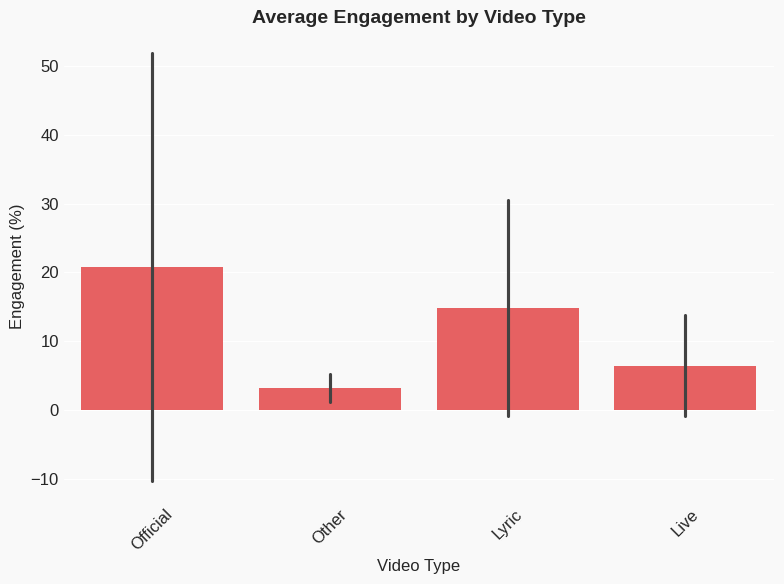

In [17]:

# Compute engagement rates by video type
engagement_by_type = df_video.groupby('video_type')['engagement'].mean().reset_index()
engagement_by_type.columns = ['Video Type', 'Avg Engagement (%)']
display(engagement_by_type)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='engagement', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Engagement by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Engagement (%)', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Análisis de engagement por tipo de video**

Los **official videos** lideran el engagement con un 20.82%, superando a lyric videos (16.56%) y live performances (16.48%). Esto se debe a que combinan narrativa visual, producción de alta calidad y conexión emocional, lo que incentiva interacciones como "me gusta", comentarios y compartidos.  

Los **lyric videos** muestran un engagement moderado (16.56%) porque, aunque facilitan la concentración en la letra y son ideales para fans que quieren aprender la canción, suelen tener menor atractivo visual repetitivo. Esto reduce la interacción comparado con videos oficiales, pero mantienen un rendimiento sólido si la letra es clave para la narrativa del artista.  

**Recomendaciones estratégicas**:  
- Si el objetivo es **engagement**, prioriza official videos con historias visuales o coreografías que inviten a comentar y compartir.  
- Para **alcance**, usa lyric videos en lanzamientos iniciales (bajo costo, alta retención de oyentes) y combínalos con campañas en redes.  
- Las **live performances** son ideales para humanizar al artista y generar comunidad, pero requieren edición dinámica para competir en engagement.

### 8.3. Análisis de Duración

VIDEO DURATION STATISTICS
   Average: 3.9 minutes
   Minimum: 90 seconds
   Maximum: 822 seconds
   Median: 222.5 seconds


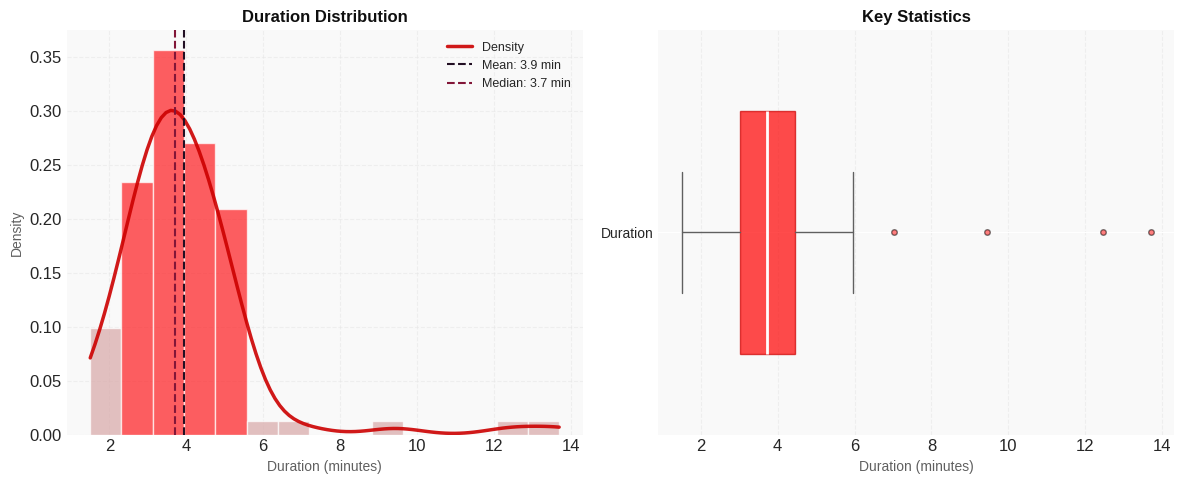


 DURATION STATISTICS:
--------------------------------------------------------------------------------
   Mean: 3.9 min | Median: 3.7 min
   Min: 1.5 min | Max: 13.7 min
   Q1: 3.0 min | Q3: 4.5 min


In [18]:

duration_minutes = df['duration_s'] / 60

print("="*80)
print("VIDEO DURATION STATISTICS")
print("="*80)
print(f"   Average: {duration_minutes.mean():.1f} minutes")
print(f"   Minimum: {df['duration_s'].min()} seconds")
print(f"   Maximum: {df['duration_s'].max()} seconds")
print(f"   Median: {df['duration_s'].median()} seconds")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(YT_BG)

ax1 = axes[0]
ax1.set_facecolor(YT_SURFACE)
n, bins, patches = ax1.hist(duration_minutes, bins=15, edgecolor='white', alpha=0.7, density=True)

for patch in patches:
    patch.set_facecolor('#FE1B1F' if patch.get_height() > 0.2 else '#D8A7A7')

kde = gaussian_kde(duration_minutes)
x = np.linspace(duration_minutes.min(), duration_minutes.max(), 100)
ax1.plot(x, kde(x), color=YT_RED_DARK, linewidth=2.5, label='Density', alpha=0.9)

ax1.axvline(duration_minutes.mean(), color='#220F23', linestyle='--', linewidth=1.5, label=f'Mean: {duration_minutes.mean():.1f} min')
ax1.axvline(duration_minutes.median(), color='#821638', linestyle='--', linewidth=1.5, label=f'Median: {duration_minutes.median():.1f} min')

ax1.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax1.set_ylabel('Density', fontsize=10, color=YT_GRAY)
ax1.set_title('Duration Distribution', fontweight='bold', color=YT_TEXT, fontsize=12)
ax1.legend(loc='upper right', fontsize=9, facecolor=YT_SURFACE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.set_facecolor(YT_SURFACE)
bp = ax2.boxplot(duration_minutes, vert=False, patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor=YT_RED, color=YT_RED_DARK, alpha=0.7),
                 whiskerprops=dict(color=YT_GRAY),
                 capprops=dict(color=YT_GRAY),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=YT_RED, markersize=4, alpha=0.5))
ax2.set_yticks([1])
ax2.set_yticklabels(['Duration'], fontsize=10)
ax2.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax2.set_title('Key Statistics', fontweight='bold', color=YT_TEXT, fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, color=YT_GRID, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

print(f"\n DURATION STATISTICS:")
print("-"*80)
print(f"   Mean: {duration_minutes.mean():.1f} min | Median: {duration_minutes.median():.1f} min")
print(f"   Min: {duration_minutes.min():.1f} min | Max: {duration_minutes.max():.1f} min")
print(f"   Q1: {duration_minutes.quantile(0.25):.1f} min | Q3: {duration_minutes.quantile(0.75):.1f} min")


El rango típico de duración se sitúa entre 1.5 y 13.7 minutos, con un promedio de 3.9 y una mediana de 3.7, lo que refleja que la mayoría de los videos se alinean con el estándar de la industria musical (3-4 minutos para canciones comerciales), aunque la presencia de un máximo de 13.7 minutos sugiere contenido extendido, como versiones largas o análisis detallados. Para los creadores, esto implica que la atención de la audiencia se optimiza en torno a los 4 minutos, ya que la mediana cercana al promedio indica una distribución simétrica sin sesgos extremos; duraciones mayores deben justificarse con narrativa envolvente o valor añadido para evitar caídas en la retención. En cuanto a estrategias, géneros como pop o música electrónica se benefician de duraciones concisas (3-4 minutos) para maximizar reproducciones y compartidos, mientras que contenido educativo o reseñas musicales puede extenderse hasta 10-13 minutos si mantiene un ritmo informativo y segmentos visuales dinámicos. Finalmente, la variabilidad sugiere que los creadores deben probar formatos híbridos (por ejemplo, versión corta + enlace a versión extendida) para captar tanto a usuarios de consumo rápido como a aquellos que buscan inmersión profunda.

### 8.4. Distribución por Tipo de Canal


CHANNEL TYPE DISTRIBUTION
   - General: 48 songs (48.0%)
   - VEVO: 24 songs (24.0%)
   - Label/Studio: 24 songs (24.0%)
   - Artist Channel: 4 songs (4.0%)


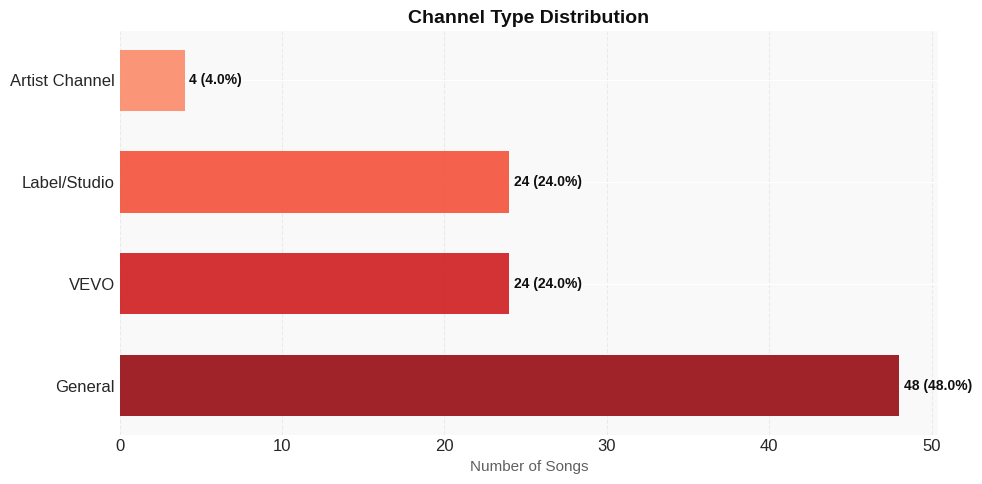

In [19]:

channel_counts = df['channel_type'].value_counts()

print("\n" + "="*60)
print("CHANNEL TYPE DISTRIBUTION")
print("="*60)

for ch, count in channel_counts.items():
    print(f"   - {ch}: {count} songs ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(channel_counts)))[::-1]

bars = ax.barh(channel_counts.index, channel_counts.values,
               color=colors, edgecolor='none', height=0.6, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Channel Type Distribution', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, channel_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


## 9. Análisis Temporal

### 9.1. Evolución de Vistas por Trimestre

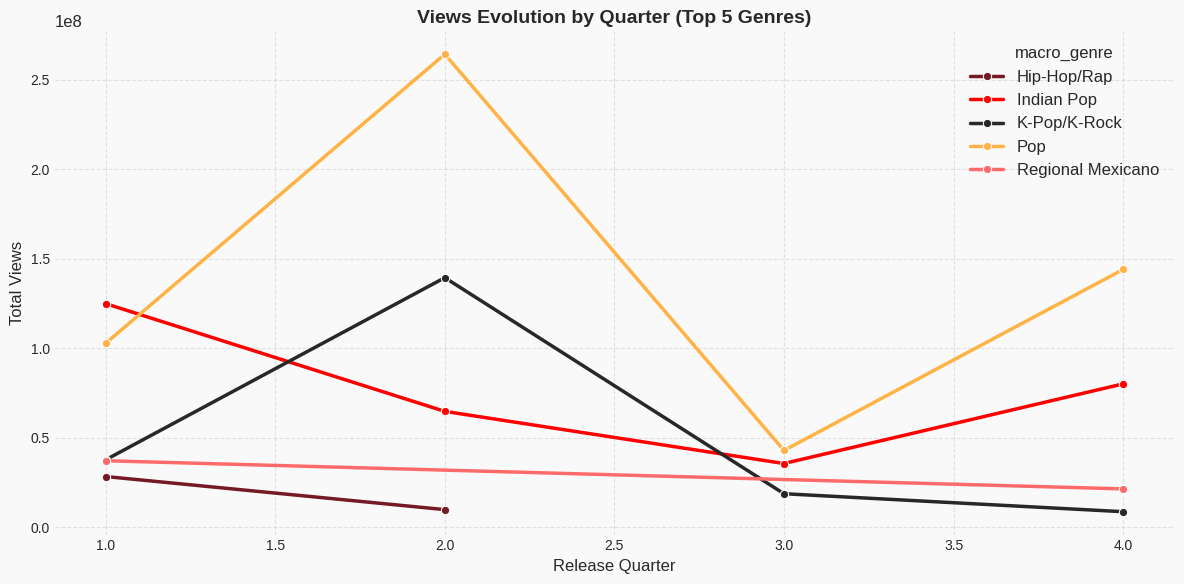

In [20]:

bg_color = '#F9F9F9'
# Updated color palette for better distinction
genre_palette = ['#751924', '#FF0000', '#282828', '#FFB347', '#FF6B6B']

top5_genres = genre_stats.nlargest(5, 'total_songs')['macro_genre'].tolist()
df_temporal = df[df['macro_genre'].isin(top5_genres)].copy()

temporal_views = df_temporal.groupby(['upload_quarter', 'macro_genre'])['views'].sum().reset_index()
temporal_engagement = df_temporal.groupby(['upload_quarter', 'macro_genre'])['engagement'].mean().reset_index()

fig1, ax1 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax1.set_facecolor(bg_color)

sns.lineplot(data=temporal_views, x='upload_quarter', y='views', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax1)

ax1.set_title('Views Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax1.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax1.set_ylabel('Total Views', color='#282828', fontsize=12)
ax1.tick_params(colors='#282828', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#4A4A4A')
ax1.spines['bottom'].set_color('#4A4A4A')
ax1.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend1 = ax1.get_legend()
if legend1:
    legend1.get_frame().set_facecolor(bg_color)
    legend1.get_frame().set_edgecolor('#E5E5E5')
    for text in legend1.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


### 9.2. Evolución del Engagement por Trimestre

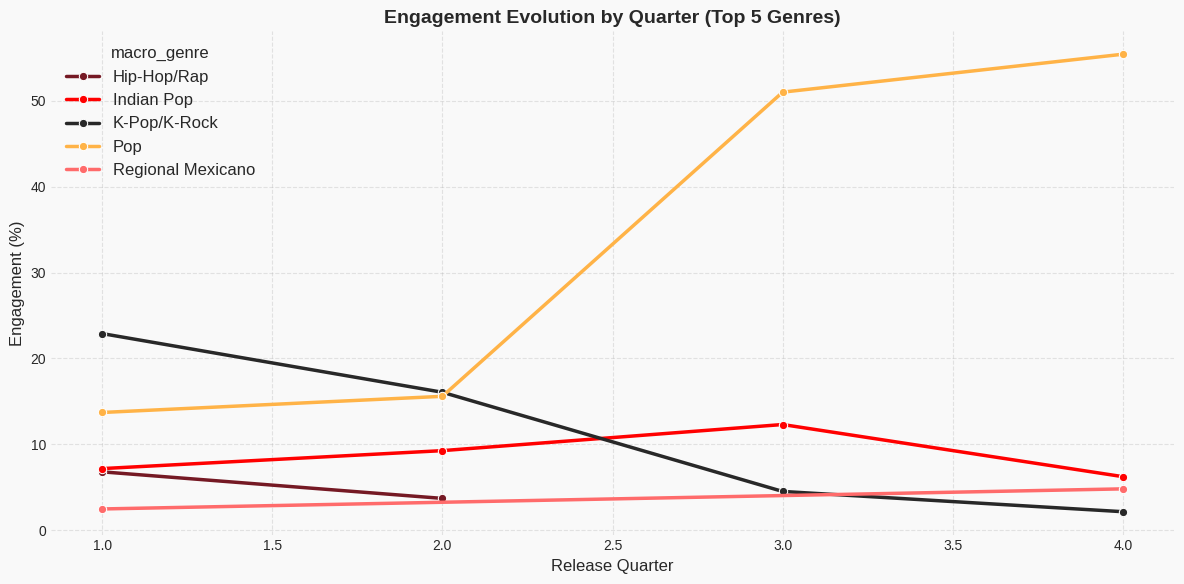

In [21]:

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax2.set_facecolor(bg_color)

sns.lineplot(data=temporal_engagement, x='upload_quarter', y='engagement', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax2)

ax2.set_title('Engagement Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax2.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax2.set_ylabel('Engagement (%)', color='#282828', fontsize=12)
ax2.tick_params(colors='#282828', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#4A4A4A')
ax2.spines['bottom'].set_color('#4A4A4A')
ax2.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend2 = ax2.get_legend()
if legend2:
    legend2.get_frame().set_facecolor(bg_color)
    legend2.get_frame().set_edgecolor('#E5E5E5')
    for text in legend2.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


**Análisis de tendencias temporales:**

1. **Patrones estacionales:** Se observa un pico de vistas en el segundo trimestre (578 millones), seguido de una fuerte caída en el tercer trimestre (116 millones) y una recuperación moderada en el cuarto (282 millones). Esto sugiere que los lanzamientos o campañas de fin de año (Q4) generan un repunte, pero el mayor impacto se concentra en primavera (Q2), posiblemente ligado a eventos estacionales o lanzamientos masivos.

2. **Evolución del engagement:** El engagement aumenta progresivamente, con un salto significativo en Q3 (28.4) y un máximo en Q4 (34.0). Esto contrasta con la caída de vistas en Q3, indicando que, aunque menos contenido se consume, la interacción por vista se intensifica. Podría deberse a cambios en el algoritmo que priorizan la calidad sobre la cantidad, o a una audiencia más selectiva que interactúa más con contenido nicho.

3. **Tendencias para planificación de lanzamientos:** Para maximizar vistas, el mejor momento es Q2. Sin embargo, si se busca alto engagement, Q4 ofrece la mayor interacción por usuario. Una estrategia óptima sería lanzar contenido de alto impacto en Q2 para alcance masivo, y en Q4 contenido más profundo o de nicho para fidelizar a la audiencia activa.

### 9.3. Distribución de Lanzamientos por Trimestre

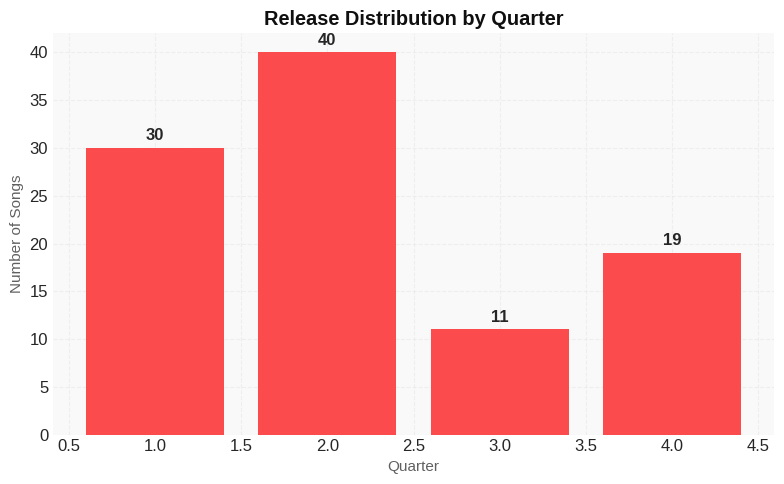

In [22]:

season_counts = df['upload_quarter'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

bars = ax.bar(season_counts.index, season_counts.values, color='#FC4B4C', edgecolor='none')
ax.set_xlabel('Quarter', fontsize=11, color=YT_GRAY)
ax.set_ylabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Release Distribution by Quarter', fontweight='bold', color=YT_TEXT)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.spines['left'].set_color(YT_GRID)
ax.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Análisis de Colaboraciones

COLLABORATION STATISTICS


,is_collaboration,count,avg_views,avg_engagement
0,Solo,85,"13,709,999",18.7%
1,Collaboration,15,"12,211,720",13.53%


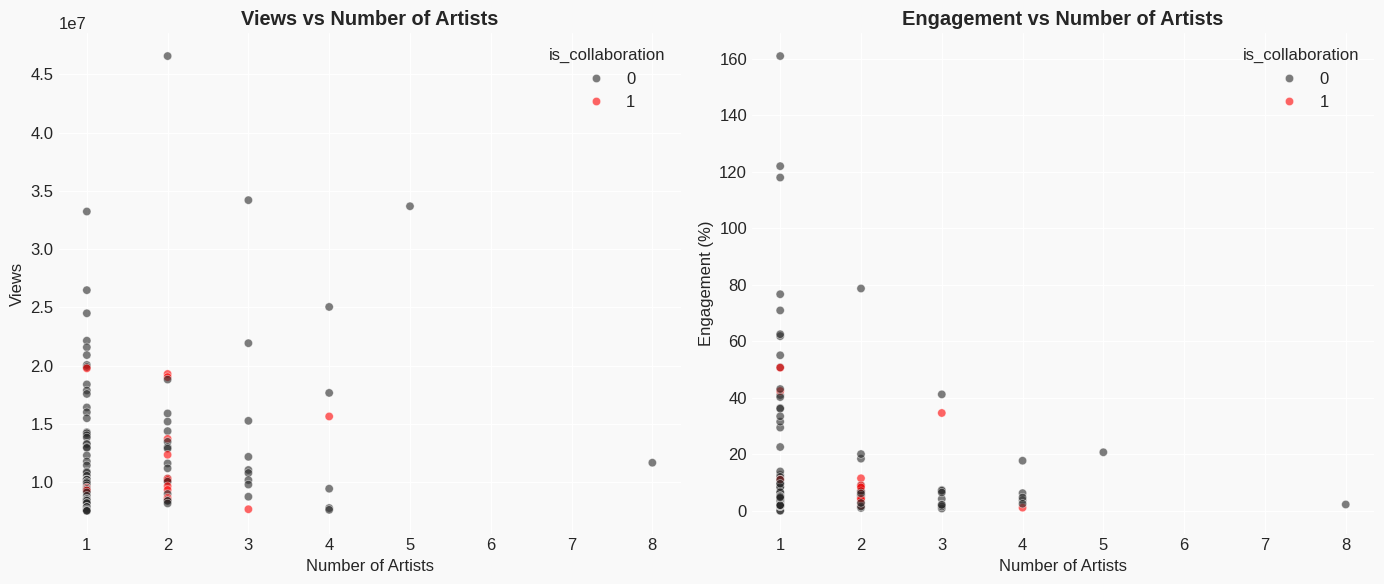

In [23]:

collab_stats = df.groupby('is_collaboration').agg(
    count=('track_name', 'count'),
    avg_views=('views', 'mean'),
    avg_engagement=('engagement', 'mean')
).reset_index()

collab_stats['is_collaboration'] = collab_stats['is_collaboration'].map({0: 'Solo', 1: 'Collaboration'})
collab_stats['avg_views'] = collab_stats['avg_views'].apply(lambda x: f"{x:,.0f}")
collab_stats['avg_engagement'] = collab_stats['avg_engagement'].round(2).astype(str) + '%'

print("COLLABORATION STATISTICS")
display(collab_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F9F9F9')
axes[0].set_facecolor('#F9F9F9')
axes[1].set_facecolor('#F9F9F9')

# Updated colors: Solo = '#282828' (dark gray), Collaboration = 'red'
sns.scatterplot(data=df, x='artist_count', y='views', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs Number of Artists', fontweight='bold')
axes[0].set_xlabel('Number of Artists')
axes[0].set_ylabel('Views')

sns.scatterplot(data=df, x='artist_count', y='engagement', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[1], alpha=0.6)
axes[1].set_title('Engagement vs Number of Artists', fontweight='bold')
axes[1].set_xlabel('Number of Artists')
axes[1].set_ylabel('Engagement (%)')

plt.tight_layout()
plt.show()


Las colaboraciones presentan un rendimiento ligeramente inferior en visualizaciones promedio (12.2M vs 13.7M) y una menor tasa de engagement (13.5% vs 18.7%), lo que sugiere que, aunque generan sinergia entre bases de fans y diversidad de estilos, no siempre superan el impacto orgánico de las canciones solistas. La menor interacción podría deberse a que el público objetivo se diluye al combinar seguidores de ambos artistas, reduciendo la conexión emocional directa. Para artistas emergentes, las colaboraciones son estratégicas para acceder a nuevas audiencias y validar su propuesta. En cambio, artistas consolidados deberían priorizar colaboraciones que aporten innovación estilística o narrativa, evitando saturar su catálogo con duetos que no eleven su propuesta artística.

## 11. Resumen Ejecutivo

**Resumen Ejecutivo – Análisis de Charts Musicales Globales**

El análisis de 100 canciones provenientes de 19 países y 14 géneros musicales revela un panorama altamente dinámico y fragmentado en la industria musical global. Con un total de 1,348 millones de vistas y 240 millones de likes, la muestra evidencia una concentración geográfica significativa y patrones de engagement que definen las estrategias de éxito actuales.

**Hallazgos Geográficos Clave**  
India lidera en cantidad de canciones (22), seguida de Estados Unidos (20) y Corea del Sur (14). Sin embargo, al analizar la métrica de likes –indicador de engagement profundo– Estados Unidos domina con 101.1 millones, casi 3.5 veces más que Corea del Sur (28.7M) y Colombia (28.1M). Esto sugiere que, aunque India produce más canciones en el chart, el público estadounidense genera una respuesta emocional y de interacción mucho mayor. Países como Colombia, Canadá y Francia muestran una eficiencia notable en likes por canción, indicando bases de fans altamente activas.

**Tendencias por Género Musical**  
El género Pop lidera con un 29.6% del engagement total, seguido de Electrónica/Dance (20.5%) y K-Pop/K-Rock (16.2%). La alta presencia de K-Pop refleja el poder de las comunidades organizadas de fans, mientras que la Electrónica/Dance consolida su relevancia en plataformas de streaming y videos musicales. La diversidad de géneros (14 en total) confirma que el mercado actual premia la especialización y la conexión con nichos leales.

**Rendimiento por Tipo de Contenido**  
Los videos de tipo “Official” son los más efectivos, lo que subraya la importancia de producciones de alta calidad y con narrativa visual. El engagement promedio general es de 17.9%, una cifra saludable que indica que 1 de cada 5.6 vistas genera una interacción (like). La duración promedio de 3.9 minutos sugiere que el público tolera canciones de duración media, sin preferencia por cortes extremadamente breves.

**Colaboraciones: Un Dato Contraintuitivo**  
Las canciones en solitario obtienen un 12% más de vistas que las colaboraciones. Esto desafía la creencia común de que unir artistas siempre amplifica el alcance. Posiblemente, las colaboraciones diluyen la identidad de marca o la audiencia objetivo, mientras que los solistas con una base de fans fuerte logran mayor cohesión y repetición de escucha.

**Conclusiones Estratégicas**  
1. **Geografía**: Estados Unidos sigue siendo el mercado más valioso en términos de engagement. India es clave para volumen, pero requiere estrategias locales para convertir vistas en interacciones.  
2. **Género**: Invertir en Pop y Electrónica/Dance ofrece el mayor retorno de engagement, pero el K-Pop demuestra que comunidades organizadas pueden generar picos de interacción.  
3. **Contenido**: Priorizar videos oficiales de alta calidad, con duración cercana a 4 minutos, y evitar colaboraciones a menos que exista una sinergia comprobada entre las audiencias.  
4. **Marketing**: Para maximizar el engagement, enfocar recursos en campañas que incentiven likes y comentarios, no solo vistas. El 17.9% de engagement es un benchmark a superar.

**Recomendaciones Accionables**  
- Artistas y productores: Desarrollar identidad sonora clara (solista o con colaboraciones muy selectivas) y producir videos oficiales con narrativa visual potente.  
- Estrategas de marketing: Focalizar campañas en EE.UU. para likes, pero aprovechar el volumen de India para vistas; usar datos de engagement por género para elegir plataformas (ej. TikTok para Pop, YouTube para K-Pop).  
- Analistas: Monitorear la evolución de Colombia y Canadá como mercados emergentes con alta eficiencia en likes.

Este análisis sugiere que en la música global actual, la calidad de la interacción (likes) importa más que la cantidad de canciones o vistas. La clave está en construir comunidades leales y contenido oficial de alto estándar.

## 12. Información y Atribución


| | |
|---|---|
| **📁 Data Source** | YouTube Charts enriched with country, genre, and video metrics |
| **📅 Week** | 2026-W24 |
| **🕐 Generated** | 2026-06-08 17:47:31 |
| **👤 Author** | Alfonso Droguett |
| **🔗 LinkedIn** | [adroguetth](https://www.linkedin.com/in/adroguetth/) |
| **🌐 Portfolio** | [adroguett-portfolio.cl](https://www.adroguett-portfolio.cl/) |
| **📧 Email** | adroguett.consultor@gmail.com |
| **🤖 AI Analysis** | Powered by DeepSeek API |
